In [30]:
import json

with open('similar_100.json', 'r') as file:
    similar = json.loads(file.read())

with open('mask_100.json', 'r') as file:
    mask = json.loads(file.read())
    
with open('random_100.json', 'r') as file:
    random = json.loads(file.read())
    
with open('mix_30_30_40.json', 'r') as file:
    mix = json.loads(file.read())

In [31]:
EPOCH_NUMBER = 100
SAMPLES_PER_EPOCH_TRAIN = len(similar['train_loss']) // EPOCH_NUMBER
SAMPLES_PER_EPOCH_TEST = len(similar['test_loss']) // EPOCH_NUMBER

In [33]:
def get_mean_by_epoch(
    data: dict,
    train_metrics = ['train_loss', 'train_acc'],
    test_metrics = ['test_loss', 'test_acc'],
):
    mean_data = {}
    for key in data.keys():
        if key in train_metrics:
            if len(data[key]) > SAMPLES_PER_EPOCH_TRAIN:
                mean_data[key] = [sum(data[key][i:i + SAMPLES_PER_EPOCH_TRAIN]) / SAMPLES_PER_EPOCH_TRAIN for i in range(0, len(data[key]), SAMPLES_PER_EPOCH_TRAIN)]
            else:
                mean_data[key] = data[key]
        if key in test_metrics:
            if len(data[key]) > SAMPLES_PER_EPOCH_TEST:
                mean_data[key] = [sum(data[key][i:i + SAMPLES_PER_EPOCH_TEST]) / SAMPLES_PER_EPOCH_TEST for i in range(0, len(data[key]), SAMPLES_PER_EPOCH_TEST)]
            else:
                mean_data[key] = data[key]
    return mean_data

mean_similar = get_mean_by_epoch(similar)
mean_mask = get_mean_by_epoch(mask)
mean_random = get_mean_by_epoch(random)
mean_mix = get_mean_by_epoch(mix)


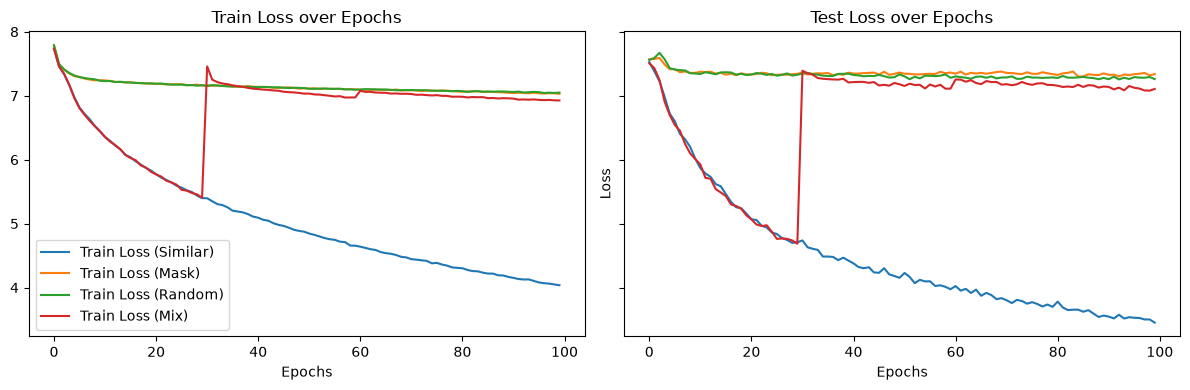

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(mean_similar['train_loss'], label='Train Loss (Similar)')
axes[0].plot(mean_mask['train_loss'], label='Train Loss (Mask)')
axes[0].plot(mean_random['train_loss'], label='Train Loss (Random)')
axes[0].plot(mean_mix['train_loss'], label='Train Loss (Mix)')
axes[0].set_title('Train Loss over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].legend()

axes[1].plot(mean_similar['test_loss'], label='Test Loss (Similar)')
axes[1].plot(mean_mask['test_loss'], label='Test Loss (Mask)')
axes[1].plot(mean_random['test_loss'], label='Test Loss (Random)')
axes[1].plot(mean_mix['test_loss'], label='Test Loss (Mix)')
axes[1].set_title('Test Loss over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[0].legend()

plt.tight_layout()
plt.show()

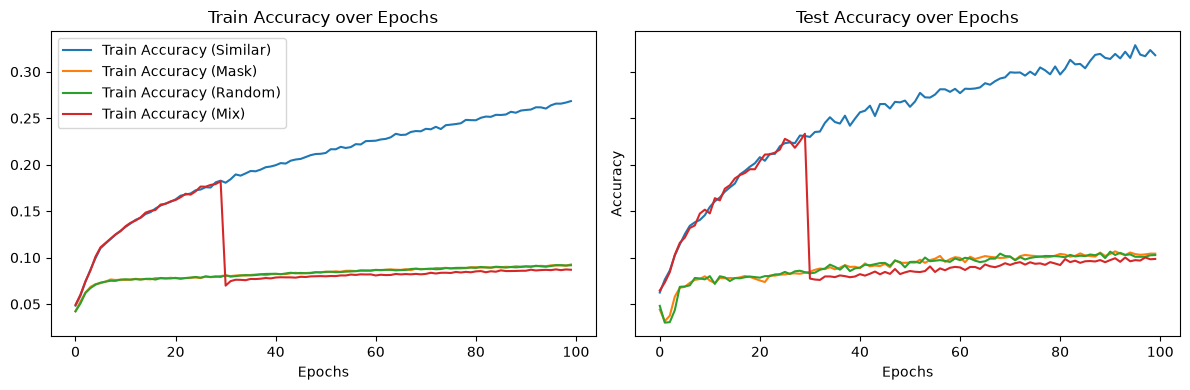

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(mean_similar['train_acc'], label='Train Accuracy (Similar)')
axes[0].plot(mean_mask['train_acc'], label='Train Accuracy (Mask)')
axes[0].plot(mean_random['train_acc'], label='Train Accuracy (Random)')
axes[0].plot(mean_mix['train_acc'], label='Train Accuracy (Mix)')
axes[0].set_title('Train Accuracy over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].legend()

axes[1].plot(mean_similar['test_acc'], label='Test Accuracy (Similar)')
axes[1].plot(mean_mask['test_acc'], label='Test Accuracy (Mask)')
axes[1].plot(mean_random['test_acc'], label='Test Accuracy (Random)')
axes[1].plot(mean_mix['test_acc'], label='Test Accuracy (Mix)')
axes[1].set_title('Test Accuracy over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[0].legend()

plt.tight_layout()
plt.show()